# Notebook #7: Evaluating Machine Teaching for XAI with Multimodal LLMs
#### by Sebastian Einar Salas Rokholt

---

**Summary**  
This notebook runs the multimodal LLM (MLLM) experiment and analyses participant-level results.

---

**Index**
1. Setup and imports
2. Run the MLLM experiment (30 participants across groups A-F)
3. Load and quality-check `participants.csv`
4. Estimate relative teaching effect versus baseline group F
5. Visualise and rank group effects


### 0 - Notebook setup and imports

In [3]:
# Standard library and PyPI imports
import os
import sys
import shlex
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# Path configuration
PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

RUN_EXPERIMENT = False  # Set to False to skip experiment execution and only run analysis/plotting

TEACHING_SET_DIR = PROJECT_ROOT / "Figures" / "teaching_sets" / "mllm_experiment_sets"
EXAM_SETS_DIR = PROJECT_ROOT / "Figures" / "exam_sets" / "mllm_experiment_sets"
METADATA_DIR = PROJECT_ROOT / "Data" / "mllm_experiment_metadata"
OUTPUT_DIR = PROJECT_ROOT / "Data" / "mllm_experiment_results" / "experiment_1"
RESULTS_CSV = OUTPUT_DIR / "participants.csv"

PARTICIPANTS_TO_RUN = 30
CONDITIONS = "all"
PARALLEL_PARTICIPANTS = 6
MODEL_NAME = "gpt-5-mini"

# Display and plotting configuration
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
sns.set_theme(style="whitegrid")

# Basic path validation
for required_path in [TEACHING_SET_DIR, EXAM_SETS_DIR, METADATA_DIR, OUTPUT_DIR]:
    if not required_path.exists():
        raise FileNotFoundError(f"Required path does not exist: {required_path}")

if not os.getenv("OPENAI_API_KEY"):
    print("Warning: OPENAI_API_KEY is not set. The experiment cell requires a valid key.")

print(f"Project root: {PROJECT_ROOT}")
print(f"Results file: {RESULTS_CSV}")


Project root: /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models
Results file: /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/mllm_experiment_results/experiment_1/participants.csv


### 1 - Run automated MT4XAI experiment on MLLM participants

In [5]:
# Run the full trial runner with 30 participants across all groups (A-F)
run_cmd = [
    sys.executable,
    "-m",
    "mllm_experiment.run_trial",
    "--participants",
    str(PARTICIPANTS_TO_RUN),
    "--conditions",
    CONDITIONS,
    "--teaching_set_dir",
    str(TEACHING_SET_DIR),
    "--exam_sets_dir",
    str(EXAM_SETS_DIR),
    "--metadata_dir",
    str(METADATA_DIR),
    "--output_dir",
    str(OUTPUT_DIR),
    "--parallel_participants",
    str(PARALLEL_PARTICIPANTS),
    "--model_name",
    MODEL_NAME,
    "--log_level",
    "INFO",
]


if RUN_EXPERIMENT:
    print("Running command:")
    print(" ".join(shlex.quote(part) for part in run_cmd))

    completed_process = subprocess.run(
        run_cmd,
        cwd=PROJECT_ROOT,
        check=True,
    )

    print(f"Trial runner finished with return code {completed_process.returncode}.")
    print(f"Participant summary file: {RESULTS_CSV}")
else: 
    print("RUN_EXPERIMENT is set to False. Skipping experiment execution and only running analysis/plotting.")

RUN_EXPERIMENT is set to False. Skipping experiment execution and only running analysis/plotting.


### 2 - Load and validate participant results

In [6]:
participants_df = pd.read_csv(RESULTS_CSV)
participants_df["group"] = participants_df["group"].astype(str).str.strip().str.upper()
participants_df["status"] = participants_df["status"].astype(str).str.strip().str.lower()

for metric_col in ["accuracy_pre", "accuracy_post", "delta_accuracy"]:
    participants_df[metric_col] = pd.to_numeric(participants_df[metric_col], errors="coerce")

group_order = list("ABCDEF")

status_counts = (
    participants_df
    .pivot_table(index="group", columns="status", values="participant_id", aggfunc="count", fill_value=0)
    .reindex(group_order)
    .fillna(0)
    .astype(int)
)

print("Participant counts by group and status")
display(status_counts)

completed_df = participants_df.loc[
    (participants_df["status"] == "completed")
    & (participants_df["group"].isin(group_order))
].copy()
completed_df = completed_df.dropna(subset=["delta_accuracy"])

if completed_df.empty:
    raise ValueError("No completed participants with valid delta_accuracy were found.")

print(f"Completed participants used for effect analysis: {len(completed_df)}")
display(completed_df.head())


Participant counts by group and status


status,completed,failed
group,,
A,5,0
B,5,0
C,5,0
D,5,0
E,4,1
F,6,0


Completed participants used for effect analysis: 30


,participant_id,group,exam_set_pre,exam_set_post,accuracy_pre,accuracy_post,delta_accuracy,status,error_type,error_message
0,p_0001_ce702016,C,set1,set2,0.8000,0.6000,-0.2000,completed,NaN,NaN
1,p_0000_cf79bd98,A,set2,set1,0.9500,0.8500,-0.1000,completed,NaN,NaN
2,p_0002_4fac5cfc,F,set1,set2,0.9000,0.8500,-0.0500,completed,NaN,NaN
3,p_0003_47e3be4a,D,set1,set2,0.7000,0.6500,-0.0500,completed,NaN,NaN
4,p_0004_8d882e7d,E,set2,set1,0.7000,0.4500,-0.2500,completed,NaN,NaN


### 3 - Relative teaching effect of groups A-E versus baseline group F

In [7]:
def bootstrap_mean_difference_ci(
    sample_group: np.ndarray,
    sample_baseline: np.ndarray,
    rng: np.random.Generator,
    n_bootstrap: int = 20_000,
    alpha: float = 0.05,
) -> tuple[float, float]:
    """Estimate a percentile bootstrap confidence interval for a mean difference.

    Args:
        sample_group: Sample values for one teaching group.
        sample_baseline: Sample values for baseline group F.
        rng: Random number generator.
        n_bootstrap: Number of bootstrap replications.
        alpha: Significance level used for the two-sided interval.

    Returns:
        Tuple with lower and upper confidence bounds.
    """
    sample_group = np.asarray(sample_group, dtype=float)
    sample_baseline = np.asarray(sample_baseline, dtype=float)

    group_idx = rng.integers(0, sample_group.size, size=(n_bootstrap, sample_group.size))
    base_idx = rng.integers(0, sample_baseline.size, size=(n_bootstrap, sample_baseline.size))
    sampled_diffs = sample_group[group_idx].mean(axis=1) - sample_baseline[base_idx].mean(axis=1)

    lower_q = alpha / 2
    upper_q = 1 - (alpha / 2)
    return float(np.quantile(sampled_diffs, lower_q)), float(np.quantile(sampled_diffs, upper_q))


group_stats = (
    completed_df.groupby("group", as_index=False)["delta_accuracy"]
    .agg(n="size", mean_delta="mean", std_delta="std")
    .set_index("group")
    .reindex(group_order)
)
print("Mean post-pre accuracy shift by group")
display(group_stats)

baseline_delta = completed_df.loc[completed_df["group"] == "F", "delta_accuracy"].to_numpy()
if baseline_delta.size == 0:
    raise ValueError("Baseline group F has no completed participants.")

baseline_mean = float(baseline_delta.mean())
effect_rows = []
rng = np.random.default_rng(42)

for group in list("ABCDE"):
    group_delta = completed_df.loc[completed_df["group"] == group, "delta_accuracy"].to_numpy()
    if group_delta.size == 0:
        continue

    relative_effect = float(group_delta.mean() - baseline_mean)
    ci_low, ci_high = bootstrap_mean_difference_ci(
        sample_group=group_delta,
        sample_baseline=baseline_delta,
        rng=rng,
    )

    _, p_value = stats.ttest_ind(group_delta, baseline_delta, equal_var=False)

    pooled_sd = np.sqrt((group_delta.var(ddof=1) + baseline_delta.var(ddof=1)) / 2)
    cohen_d = float(relative_effect / pooled_sd) if pooled_sd > 0 else np.nan

    effect_rows.append(
        {
            "group": group,
            "n_group": int(group_delta.size),
            "mean_delta_accuracy": float(group_delta.mean()),
            "baseline_mean_delta_F": baseline_mean,
            "relative_teaching_effect": relative_effect,
            "relative_teaching_effect_pp": relative_effect * 100,
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "welch_p_value": float(p_value),
            "cohen_d_vs_F": cohen_d,
        }
    )

effect_df = pd.DataFrame(effect_rows).sort_values(
    by="relative_teaching_effect",
    ascending=False,
    ignore_index=True,
)

print("Relative teaching effect definition")
print("relative_teaching_effect = mean(delta_accuracy_group) - mean(delta_accuracy_group_F)")
print("Positive values indicate better post-pre accuracy change than baseline F.")

display(effect_df)


Mean post-pre accuracy shift by group


,n,mean_delta,std_delta
group,,,
A,5,-0.0900,0.0548
B,5,-0.0500,0.1275
C,5,-0.1600,0.1710
D,5,-0.0700,0.1681
E,4,-0.2250,0.0866
F,6,-0.0667,0.1366


Relative teaching effect definition
relative_teaching_effect = mean(delta_accuracy_group) - mean(delta_accuracy_group_F)
Positive values indicate better post-pre accuracy change than baseline F.


,group,n_group,mean_delta_accuracy,baseline_mean_delta_F,relative_teaching_effect,relative_teaching_effect_pp,ci95_low,ci95_high,welch_p_value,cohen_d_vs_F
0,B,5,-0.0500,-0.0667,0.0167,1.6667,-0.1217,0.1583,0.8392,0.1261
1,D,5,-0.0700,-0.0667,-0.0033,-0.3333,-0.1583,0.1700,0.9725,-0.0218
2,A,5,-0.0900,-0.0667,-0.0233,-2.3333,-0.1283,0.0867,0.7134,-0.2242
3,C,5,-0.1600,-0.0667,-0.0933,-9.3333,-0.2583,0.0684,0.3543,-0.6030
4,E,4,-0.2250,-0.0667,-0.1583,-15.8333,-0.2750,-0.0292,0.0552,-1.3842


### 4 - Visualisation and ranking

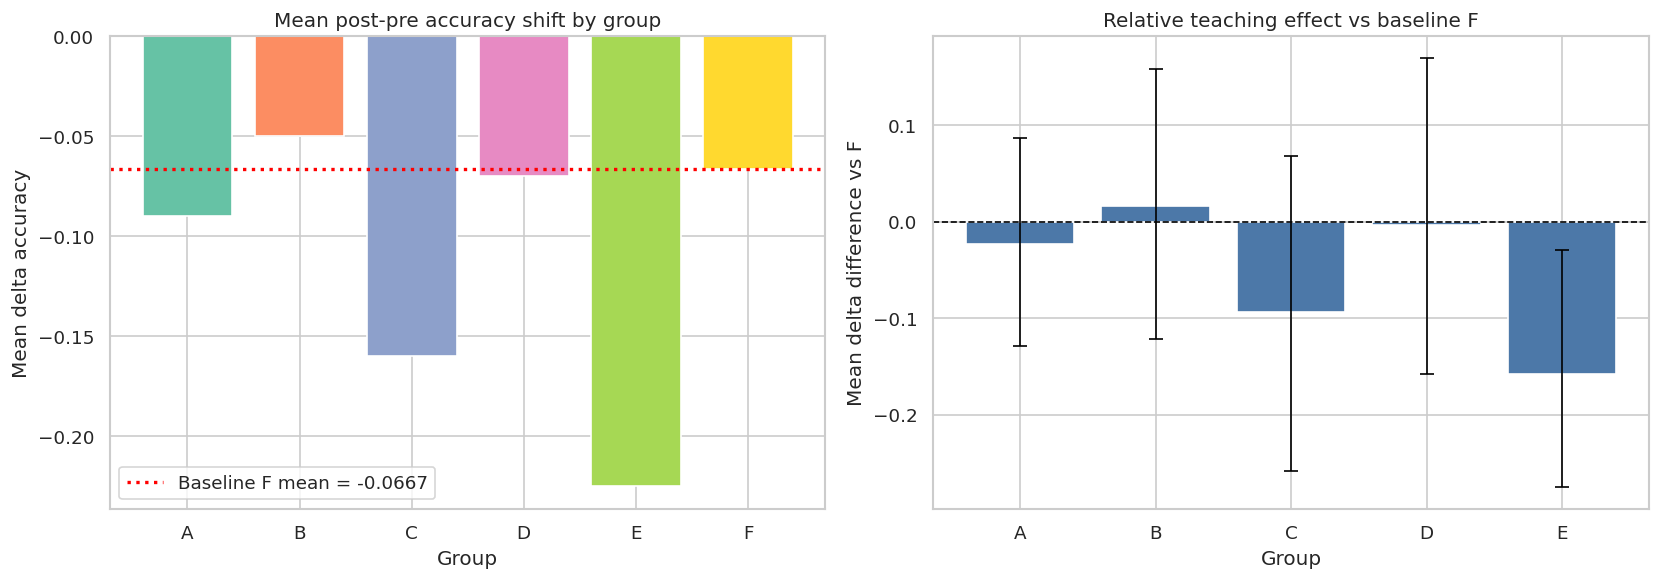

Group ranking by relative teaching effect (best to worst)


,group,relative_teaching_effect,relative_teaching_effect_pp,welch_p_value,cohen_d_vs_F
0,B,0.0167,1.6667,0.8392,0.1261
1,D,-0.0033,-0.3333,0.9725,-0.0218
2,A,-0.0233,-2.3333,0.7134,-0.2242
3,C,-0.0933,-9.3333,0.3543,-0.6030
4,E,-0.1583,-15.8333,0.0552,-1.3842


In [8]:
plot_stats_df = group_stats.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

axes[0].bar(
    plot_stats_df["group"],
    plot_stats_df["mean_delta"],
    color=["#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3", "#A6D854", "#FFD92F"],
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].axhline(
    baseline_mean,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Baseline F mean = {baseline_mean:.4f}",
)
axes[0].set_title("Mean post-pre accuracy shift by group")
axes[0].set_xlabel("Group")
axes[0].set_ylabel("Mean delta accuracy")
axes[0].legend()

plot_effect_df = effect_df.sort_values("group").copy()
axes[1].bar(
    plot_effect_df["group"],
    plot_effect_df["relative_teaching_effect"],
    color="#4C78A8",
)
axes[1].errorbar(
    x=plot_effect_df["group"],
    y=plot_effect_df["relative_teaching_effect"],
    yerr=[
        plot_effect_df["relative_teaching_effect"] - plot_effect_df["ci95_low"],
        plot_effect_df["ci95_high"] - plot_effect_df["relative_teaching_effect"],
    ],
    fmt="none",
    ecolor="black",
    capsize=4,
    linewidth=1,
)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Relative teaching effect vs baseline F")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Mean delta difference vs F")

plt.tight_layout()
plt.show()

ranking_df = effect_df[["group", "relative_teaching_effect", "relative_teaching_effect_pp", "welch_p_value", "cohen_d_vs_F"]].copy()
print("Group ranking by relative teaching effect (best to worst)")
display(ranking_df)
